In [3]:
import pandas as pd
import numpy as np
import os

# --- 1. CONFIGURATION ---
FILE_WEATHER = 'data/Ostrava_pocasi.xlsx'
FILE_BIKES = 'data/nextbike_data_VSB_Vaclavik.xlsx'
SHEET_LOGS = 'Stanice_Ostrava'

# Station to check (Exact substring match)
TARGET_STATIONS = ['Hlavní nádraží', 'Hlavní nádraží - přednádraží']

print(f"🔍 DIAGNOSTIC START: Checking Bad Weather Data...")

# --- 2. LOAD WEATHER (Handle '11,7' decimals) ---
if not os.path.exists(FILE_WEATHER):
    print(f"CRITICAL ERROR: File {FILE_WEATHER} not found.")
else:
    # Load with comma decimal support
    df_w = pd.read_excel(FILE_WEATHER, decimal=',')

    # Normalize columns (lowercase + strip)
    df_w.columns = [str(c).lower().strip() for c in df_w.columns]

    # Explicit mapping based on your screenshot
    # We look for 'datetime' (from your screenshot)
    time_col = next((c for c in df_w.columns if c in ['datetime', 'date', 'cas']), None)
    temp_col = 'temp'   # Explicitly from screenshot
    rain_col = 'precip' # Explicitly from screenshot

    if not time_col:
        print(f"❌ ERROR: Weather time column missing. Found: {df_w.columns}")
    else:
        # Convert to datetime (handles the 'T' separator automatically)
        df_w['timestamp'] = pd.to_datetime(df_w[time_col])

        # Ensure numbers are floats (handle potential comma leftovers)
        for col in [temp_col, rain_col]:
            if df_w[col].dtype == 'object':
                 df_w[col] = df_w[col].astype(str).str.replace(',', '.')
            df_w[col] = pd.to_numeric(df_w[col], errors='coerce')

        # Resample to 1 minute
        w_res = df_w.set_index('timestamp').resample('1min').ffill()
        print(f"✅ Weather loaded. Temp range: {w_res[temp_col].min()}°C to {w_res[temp_col].max()}°C")

# --- 3. LOAD LOGS (Handle 'Čas') ---
if not os.path.exists(FILE_BIKES):
    print(f"CRITICAL ERROR: File {FILE_BIKES} not found.")
else:
    df_l = pd.read_excel(FILE_BIKES, sheet_name=SHEET_LOGS)

    # Do NOT lowercase columns yet, to preserve 'Čas' for inspection if needed
    # But for matching, we will check case-insensitively

    # Find Time Column (Looking for 'Čas')
    l_time_col = None
    for col in df_l.columns:
        if col.strip() in ['Čas', 'Cas', 'time', 'Time', 'datetime']:
            l_time_col = col
            break

    if not l_time_col:
        print(f"❌ ERROR: Log time column 'Čas' not found. Found: {list(df_l.columns)}")
    else:
        print(f"✅ Found Log Time Column: '{l_time_col}'")
        df_l['timestamp'] = pd.to_datetime(df_l[l_time_col])

        # Find columns for our target stations (Case insensitive search)
        found_cols = []
        for target in TARGET_STATIONS:
            # Check every column in the excel file
            for sheet_col in df_l.columns:
                if target.lower() in sheet_col.lower():
                    found_cols.append(sheet_col)
                    # Don't break, keep looking for variants

        # Remove duplicates
        found_cols = list(set(found_cols))

        if not found_cols:
            print(f"❌ ERROR: Could not find log columns for {TARGET_STATIONS}!")
        else:
            print(f"✅ Found Log Data Columns: {found_cols}")

            # Sum availability & Resample
            log_stock = df_l.set_index('timestamp')[found_cols].fillna(0).sum(axis=1).resample('1min').ffill()

# --- 4. ANALYZE ---
if 'w_res' in locals() and 'log_stock' in locals():
    # Common Timeline
    start = max(w_res.index.min(), log_stock.index.min())
    end = min(w_res.index.max(), log_stock.index.max())
    timeline = pd.date_range(start, end, freq='1min')

    # Reindex
    w_final = w_res.reindex(timeline, method='nearest')
    stock_final = log_stock.reindex(timeline, method='nearest')

    # Masks
    t_val = w_final[temp_col]
    r_val = w_final[rain_col]

    # Bad Weather: Rain > 0.2 OR Temp < 10
    mask_bad = (r_val > 0.2) | (t_val < 10)

    # Available: Stock > 0
    mask_avail = stock_final > 0

    # Overlap
    mask_valid = mask_bad & mask_avail

    # Results
    total = len(timeline)
    bad_mins = mask_bad.sum()
    avail_during_bad = (mask_bad & mask_avail).sum()

    print("\n📊 --- DIAGNOSTIC REPORT ---")
    print(f"Total Minutes Analyzed: {total}")
    print(f"Bad Weather Minutes:    {bad_mins} ({(bad_mins/total)*100:.1f}%)")
    print(f"Station Active during Bad Weather: {avail_during_bad} minutes")

    if avail_during_bad < 60:
        print("🚨 CONCLUSION: NaN is correct.")
        print(f"   Reason: During the {bad_mins} minutes of bad weather, the station log reported >0 bikes for only {avail_during_bad} minutes.")
        print("   Meaning: When it rains, this station is recorded as EMPTY.")
    else:
        print("✅ Data looks good. The NaN in the main script might be due to train schedule overlap.")


🔍 DIAGNOSTIC START: Checking Bad Weather Data...


C:\Users\vacla\PycharmProjects\Nextbike\.venv\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


✅ Weather loaded. Temp range: -1.2°C to 26.3°C
✅ Found Log Time Column: 'Čas'
✅ Found Log Data Columns: ['MOAP-Hlavní nádraží']

📊 --- DIAGNOSTIC REPORT ---
Total Minutes Analyzed: 50336
Bad Weather Minutes:    31981 (63.5%)
Station Active during Bad Weather: 26522 minutes
✅ Data looks good. The NaN in the main script might be due to train schedule overlap.


⏳ Loading Data...


C:\Users\vacla\PycharmProjects\Nextbike\.venv\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


🎨 Generatng Forensic Plot...


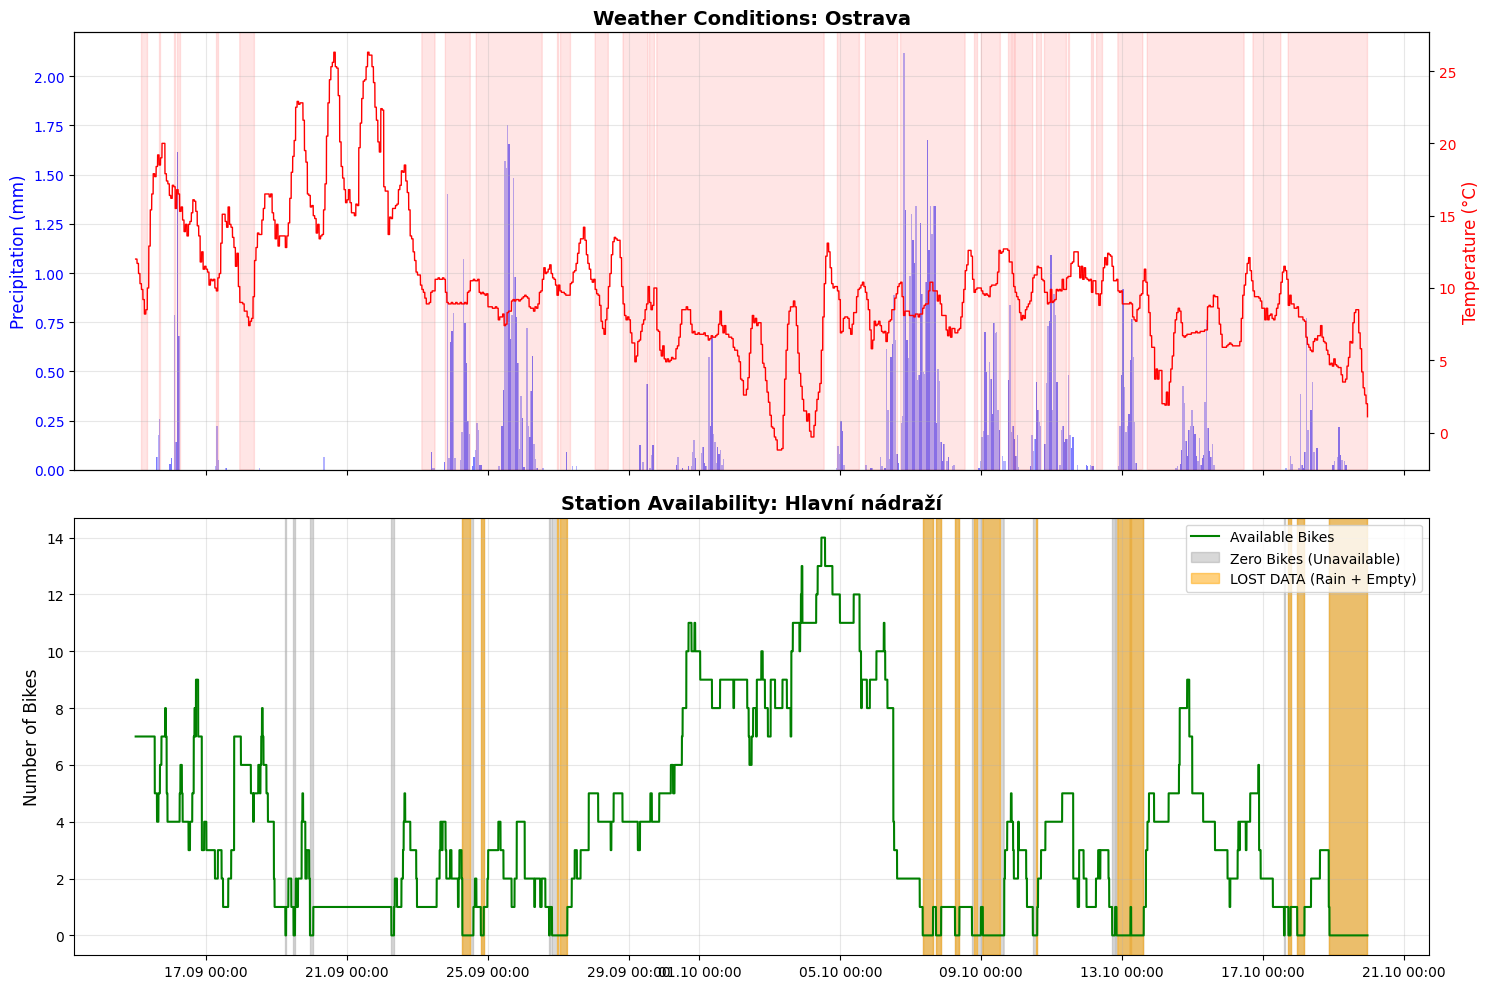

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import os

# --- 1. CONFIGURATION ---
FILE_WEATHER = 'data/Ostrava_pocasi.xlsx'
FILE_BIKES = 'data/nextbike_data_VSB_Vaclavik.xlsx'
SHEET_LOGS = 'Stanice_Ostrava'
TARGET_STATIONS = ['Hlavní nádraží', 'Hlavní nádraží - přednádraží']

# ZOOM WINDOW (Optional: Set this to a rainy week to see details)
# Set to None to see the whole month, or use strings like '2025-09-13'
ZOOM_START = None
ZOOM_END = None

# --- 2. LOAD DATA (With Fixes) ---
print("⏳ Loading Data...")

# A. Weather
df_w = pd.read_excel(FILE_WEATHER, decimal=',')
df_w.columns = [str(c).lower().strip() for c in df_w.columns]
w_time_col = next((c for c in df_w.columns if c in ['datetime', 'date', 'cas']), None)
df_w['timestamp'] = pd.to_datetime(df_w[w_time_col])

# Ensure numeric
for col in ['temp', 'precip']:
    if col in df_w.columns:
        df_w[col] = pd.to_numeric(df_w[col], errors='coerce')

w_res = df_w.set_index('timestamp').resample('1min').ffill()

# B. Logs (Bikes)
df_l = pd.read_excel(FILE_BIKES, sheet_name=SHEET_LOGS)
l_time_col = next((c for c in df_l.columns if str(c).strip() in ['Čas', 'Cas', 'time']), None)
df_l['timestamp'] = pd.to_datetime(df_l[l_time_col])

# Find station columns
found_cols = []
for target in TARGET_STATIONS:
    for col in df_l.columns:
        if target.lower() in col.lower():
            found_cols.append(col)
found_cols = list(set(found_cols))

# Sum stock
log_stock = df_l.set_index('timestamp')[found_cols].fillna(0).sum(axis=1).resample('1min').ffill()

# --- 3. ALIGN & MASK ---
start = max(w_res.index.min(), log_stock.index.min())
end = min(w_res.index.max(), log_stock.index.max())
timeline = pd.date_range(start, end, freq='1min')

w_final = w_res.reindex(timeline, method='nearest')
stock_final = log_stock.reindex(timeline, method='nearest')

# Define "Bad Weather" (Rain > 0.2 OR Temp < 10)
mask_rain = w_final['precip'] > 0.2
mask_cold = w_final['temp'] < 10
mask_bad = mask_rain | mask_cold

# Define "Empty"
mask_empty = stock_final == 0

# --- 4. PLOTTING ---
print("🎨 Generatng Forensic Plot...")
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10), sharex=True)

# === TOP PANEL: WEATHER ===
# Plot Rain
ax1.bar(timeline, w_final['precip'], color='blue', alpha=0.3, label='Rain (mm)', width=0.001)
ax1.set_ylabel('Precipitation (mm)', color='blue', fontsize=12)
ax1.tick_params(axis='y', labelcolor='blue')

# Plot Temp (Twin Axis)
ax1b = ax1.twinx()
ax1b.plot(timeline, w_final['temp'], color='red', linewidth=1, label='Temp (°C)')
ax1b.set_ylabel('Temperature (°C)', color='red', fontsize=12)
ax1b.tick_params(axis='y', labelcolor='red')

# Highlight Bad Weather Zones
ax1.fill_between(timeline, 0, 1, where=mask_bad, color='red', alpha=0.1, transform=ax1.get_xaxis_transform(), label='Bad Weather Cond.')
ax1.set_title(f"Weather Conditions: Ostrava", fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)

# === BOTTOM PANEL: BIKE AVAILABILITY ===
ax2.plot(timeline, stock_final, color='green', linewidth=1.5, label='Available Bikes')
ax2.set_ylabel('Number of Bikes', fontsize=12)

# Highlight Empty Zones
ax2.fill_between(timeline, 0, 1, where=mask_empty, color='grey', alpha=0.3, transform=ax2.get_xaxis_transform(), label='Zero Bikes (Unavailable)')

# Highlight "MISSING DATA CAUSE" (Overlap)
# Where is it Bad Weather AND Empty? This is the "NaN Zone"
mask_nan_cause = mask_bad & mask_empty
ax2.fill_between(timeline, 0, 1, where=mask_nan_cause, color='orange', alpha=0.5, transform=ax2.get_xaxis_transform(), label='LOST DATA (Rain + Empty)')

ax2.set_title(f"Station Availability: {TARGET_STATIONS[0]}", fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.legend(loc='upper right')

# Formatting
if ZOOM_START:
    ax2.set_xlim(pd.to_datetime(ZOOM_START), pd.to_datetime(ZOOM_END))

ax2.xaxis.set_major_formatter(mdates.DateFormatter('%d.%m %H:%M'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [5]:
import pandas as pd
import numpy as np
import os

# --- 1. CONFIGURATION ---
FILE_WEATHER = 'data/Ostrava_pocasi.xlsx'
FILE_BIKES = 'data/nextbike_data_VSB_Vaclavik.xlsx'
SHEET_LOGS = 'Stanice_Ostrava'
TARGET_STATIONS = ['Hlavní nádraží', 'Hlavní nádraží - přednádraží']

print(f"📉 ANALYZING: Impact of Weather on Availability at {TARGET_STATIONS[0]}...")

# --- 2. ROBUST DATA LOADING (With Comma Fix) ---
# Load Weather
if os.path.exists(FILE_WEATHER):
    df_w = pd.read_excel(FILE_WEATHER, decimal=',')
    df_w.columns = [str(c).lower().strip() for c in df_w.columns]

    # Find columns
    time_col = next((c for c in df_w.columns if c in ['datetime', 'date', 'cas']), None)
    temp_col = 'temp'
    rain_col = 'precip'

    # Fix formatting
    df_w['timestamp'] = pd.to_datetime(df_w[time_col])
    for col in [temp_col, rain_col]:
        if df_w[col].dtype == 'object':
             df_w[col] = df_w[col].astype(str).str.replace(',', '.')
        df_w[col] = pd.to_numeric(df_w[col], errors='coerce')

    w_res = df_w.set_index('timestamp').resample('1min').ffill()
else:
    print("Error: Weather file not found.")

# Load Logs
if os.path.exists(FILE_BIKES):
    df_l = pd.read_excel(FILE_BIKES, sheet_name=SHEET_LOGS)

    # Find Time Column
    l_time_col = None
    for col in df_l.columns:
        if col.strip() in ['Čas', 'Cas', 'time', 'Time', 'datetime']:
            l_time_col = col
            break

    df_l['timestamp'] = pd.to_datetime(df_l[l_time_col])

    # Find target station columns
    found_cols = []
    for target in TARGET_STATIONS:
        for col in df_l.columns:
            if target.lower() in col.lower():
                found_cols.append(col)
    found_cols = list(set(found_cols))

    # Sum stock & Resample
    log_stock = df_l.set_index('timestamp')[found_cols].fillna(0).sum(axis=1).resample('1min').ffill()
else:
    print("Error: Bike file not found.")

# --- 3. ALIGNMENT & MASKS ---
start = max(w_res.index.min(), log_stock.index.min())
end = min(w_res.index.max(), log_stock.index.max())
timeline = pd.date_range(start, end, freq='1min')

# Reindex to common timeline
w_final = w_res.reindex(timeline, method='nearest')
stock_final = log_stock.reindex(timeline, method='nearest')

# --- 4. CREATE BINARY VARIABLES ---
# Variable X: Bad Weather (1 = Bad, 0 = Good)
x_bad_weather = ((w_final['precip'] > 0.2) | (w_final['temp'] < 10)).astype(int)

# Variable Y: Unavailability (1 = Empty, 0 = Available)
y_unavailable = (stock_final == 0).astype(int)

# --- 5. STATISTICAL CALCULATIONS ---
# A. Pearson Correlation (Phi Coefficient)
correlation = x_bad_weather.corr(y_unavailable)

# B. Conditional Probabilities
total_bad_mins = x_bad_weather.sum()
total_good_mins = len(x_bad_weather) - total_bad_mins

empty_during_bad = (x_bad_weather & y_unavailable).sum()
empty_during_good = ((x_bad_weather == 0) & y_unavailable).sum()

prob_empty_bad = (empty_during_bad / total_bad_mins) * 100
prob_empty_good = (empty_during_good / total_good_mins) * 100

risk_multiplier = prob_empty_bad / prob_empty_good if prob_empty_good > 0 else np.nan

# --- 6. OUTPUT RESULTS ---
print("\n📊 --- STATISTICAL RESULTS ---")
print(f"1. Correlation Coefficient:  {correlation:.4f}")
print("   (Positive = Bad weather leads to empty stations)")
print("-" * 30)
print(f"2. Probability of Empty Station:")
print(f"   - During BAD Weather:     {prob_empty_bad:.2f}%")
print(f"   - During GOOD Weather:    {prob_empty_good:.2f}%")
print("-" * 30)
print(f"3. IMPACT FACTOR:            {risk_multiplier:.2f}x")
print(f"   (The station is {risk_multiplier:.1f} times more likely to be empty when it rains.)")

📉 ANALYZING: Impact of Weather on Availability at Hlavní nádraží...


C:\Users\vacla\PycharmProjects\Nextbike\.venv\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")



📊 --- STATISTICAL RESULTS ---
1. Correlation Coefficient:  0.1226
   (Positive = Bad weather leads to empty stations)
------------------------------
2. Probability of Empty Station:
   - During BAD Weather:     17.07%
   - During GOOD Weather:    8.27%
------------------------------
3. IMPACT FACTOR:            2.06x
   (The station is 2.1 times more likely to be empty when it rains.)


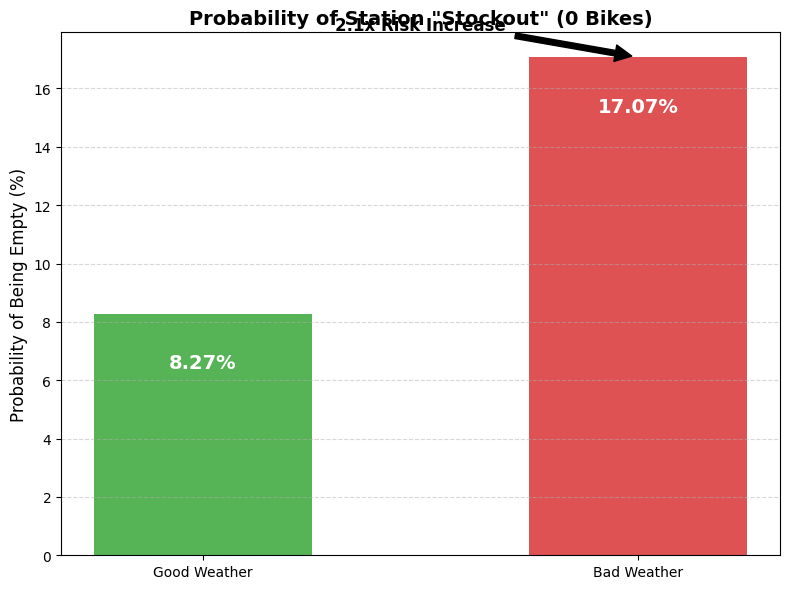

In [6]:
import matplotlib.pyplot as plt

# Your results
probs = [8.27, 17.07]
labels = ['Good Weather', 'Bad Weather']
colors = ['#2ca02c', '#d62728'] # Green vs Red

plt.figure(figsize=(8, 6))
bars = plt.bar(labels, probs, color=colors, alpha=0.8, width=0.5)

# Add title and labels
plt.title('Probability of Station "Stockout" (0 Bikes)', fontsize=14, fontweight='bold')
plt.ylabel('Probability of Being Empty (%)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Add the "2x" arrow
plt.annotate('2.1x Risk Increase',
             xy=(1, 17.07), xytext=(0.5, 18),
             arrowprops=dict(facecolor='black', shrink=0.05),
             fontsize=12, fontweight='bold', ha='center')

# Add values on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height - 2,
             f'{height:.2f}%',
             ha='center', va='bottom', color='white', fontweight='bold', fontsize=14)

plt.tight_layout()
plt.show()
